In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load the CSV file
df = pd.read_csv(r"C:\Users\mallu\Downloads\owid-co2-data.csv")

print("First 10 Rows:")
print(df.head(10))

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nShape (rows, columns):", df.shape)

First 10 Rows:
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   
5  Afghanistan  1755      AFG         NaN  NaN         0.0   
6  Afghanistan  1756      AFG         NaN  NaN         0.0   
7  Afghanistan  1757      AFG         NaN  NaN         0.0   
8  Afghanistan  1758      AFG         NaN  NaN         0.0   
9  Afghanistan  1759      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                 

# Descrption of key columns
-**co2** : carbon dioxide emmision by the country.
-**co2_per_capita** :  total co2 emission of country divided by to total number of people of a country.
-**methane** : methane gas emitted by each country.
-**nitrous_oxide** : nitrous oxide emissions produced by the country.
-**total_ghg** : total greenhouse gas emissions including co2, methane,nitrous oxide & other greenhouse gas.
-**country** :the name of the country for which green house gas emision is recorded.
-**year**: the year in which the emission data is collected.

In [2]:
# Null values per column as percentage of total rows
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage = null_percentage.sort_values(ascending=False)

print("Null Values per Column (% of total rows):")
print(null_percentage.round(2))

Null Values per Column (% of total rows):
share_global_cumulative_other_co2       95.70
share_global_other_co2                  95.70
other_co2_per_capita                    94.73
cumulative_other_co2                    93.55
other_industry_co2                      93.55
                                        ...  
share_of_temperature_change_from_ghg    18.20
temperature_change_from_co2             18.20
iso_code                                15.73
year                                     0.00
country                                  0.00
Length: 79, dtype: float64


In [3]:
# Completeness per row (% of non-null columns)
df['completeness'] = df.notnull().mean(axis=1) * 100

country_completeness = (
    df.groupby('country')['completeness']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Countries by Data Completeness:")
print(country_completeness.head(10).round(2))

year_completeness = (
    df.groupby('year')['completeness']
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 Years by Data Completeness:")
print(year_completeness.head(10).round(2))

Top 10 Countries by Data Completeness:
country
Czechia        78.18
Slovakia       77.74
Switzerland    75.52
Russia         75.43
Italy          75.10
Finland        75.04
Denmark        74.84
Estonia        74.81
Belarus        74.81
Ukraine        74.81
Name: completeness, dtype: float64

Top 10 Years by Data Completeness:
year
2011    77.80
2010    77.75
2019    77.71
2018    77.68
2015    77.68
2021    77.66
2022    77.66
2017    77.66
2020    77.66
2016    77.63
Name: completeness, dtype: float64


In [4]:
# Aggregate / non-sovereign entities to exclude (regions, income groups, trade blocs, etc.)
aggregates_to_exclude = [
    'World', 'Asia', 'Europe', 'Africa', 'North America', 'South America', 'Oceania',
    'European Union (27)', 'European Union (28)',
    'High-income countries', 'Low-income countries',
    'Upper-middle-income countries', 'Lower-middle-income countries',
    'Asia (excl. China and India)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
    'North America (excl. USA)',
    'International transport', 'International aviation', 'International shipping',
    'Kuwaiti Oil Fires', 'Kuwaiti Oil Fires (GCP)',
    'OECD (GCP)', 'OECD (Jones et al.)', 'Non-OECD (GCP)', 'G20', 'G7',
    'Africa (GCP)', 'Asia (GCP)', 'Europe (GCP)', 'Middle East (GCP)',
    'North America (GCP)', 'Oceania (GCP)', 'South America (GCP)',
    'Central America (GCP)', 'Ryukyu Islands (GCP)'
]

# Apply filters: year >= 1990, exclude aggregates (keep ALL real countries)
df_filtered = df[
    (df['year'] >= 1990) &
    (~df['country'].isin(aggregates_to_exclude))
].copy()

print("Filtered dataset shape:", df_filtered.shape)
print("Number of countries included:", df_filtered['country'].nunique())
print("Year range:", df_filtered['year'].min(), "-", df_filtered['year'].max())
df_filtered.head(10)

Filtered dataset shape: (7735, 80)
Number of countries included: 221
Year range: 1990 - 2024


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,completeness
240,Afghanistan,1990,AFG,12045664.0,1.306598e+10,0.046,0.004,2.024,-0.741,-26.784,...,0.090,0.0,0.000,0.001,0.0,13.519,3.123,NaN,NaN,87.341772
241,Afghanistan,1991,AFG,12238879.0,1.204736e+10,0.046,0.004,1.914,-0.110,-5.435,...,0.088,0.0,0.000,0.001,0.0,13.711,3.038,NaN,NaN,87.341772
242,Afghanistan,1992,AFG,13278983.0,1.267754e+10,0.046,0.003,1.482,-0.432,-22.580,...,0.087,0.0,0.000,0.001,0.0,11.543,2.606,NaN,NaN,87.341772
243,Afghanistan,1993,AFG,14943175.0,9.834582e+09,0.047,0.003,1.487,0.005,0.330,...,0.085,0.0,0.000,0.001,0.0,10.454,2.664,NaN,NaN,87.341772
244,Afghanistan,1994,AFG,16250800.0,7.919856e+09,0.047,0.003,1.454,-0.033,-2.227,...,0.084,0.0,0.000,0.001,0.0,10.980,2.697,NaN,NaN,87.341772
245,Afghanistan,1995,AFG,17065837.0,1.230753e+10,0.047,0.003,1.417,-0.037,-2.511,...,0.082,0.0,0.000,0.001,0.0,12.110,2.730,NaN,NaN,87.341772
246,Afghanistan,1996,AFG,17763266.0,1.207013e+10,0.047,0.003,1.370,-0.047,-3.332,...,0.081,0.0,0.000,0.001,0.0,14.851,2.745,NaN,NaN,87.341772
247,Afghanistan,1997,AFG,18452100.0,1.185075e+10,0.047,0.003,1.304,-0.066,-4.814,...,0.080,0.0,0.001,0.001,0.0,18.057,2.735,NaN,NaN,87.341772
248,Afghanistan,1998,AFG,19159996.0,1.169217e+10,0.047,0.002,1.279,-0.026,-1.967,...,0.080,0.0,0.001,0.001,0.0,16.691,2.750,NaN,NaN,87.341772
249,Afghanistan,1999,AFG,19887792.0,1.151732e+10,0.047,0.002,1.092,-0.187,-14.616,...,0.079,0.0,0.001,0.001,0.0,18.338,2.603,NaN,NaN,87.341772


Filtering Decisions and Justification

The original OWID dataset contains 50,411 rows across 254 entities, covering the years 1750–2024. Before analysis, two filters were applied to create a clean country-level dataset.

1. Keep data from 1990 onwards

Only records from 1990–2024 were kept because earlier data has many missing values for important variables like total_ghg, methane, nitrous_oxide, and gdp. In addition, 1990 is the standard baseline year used in many international climate agreements, making it a meaningful starting point for the analysis.

2. Remove non-country entities

The dataset includes entries such as World, Asia, Europe, G20, OECD, and other regional or economic groups along with individual countries. These were removed because they represent combined totals rather than actual countries. Keeping them would lead to double-counting and produce misleading results in country-level analysis. A curated list of these aggregate entities was used to filter them out.

Final Dataset

After applying these filters, the dataset contains 7,735 rows covering 221 sovereign countries from 1990–2024. This provides a clean and reliable dataset for further analysis, visualization, and feature engineering.

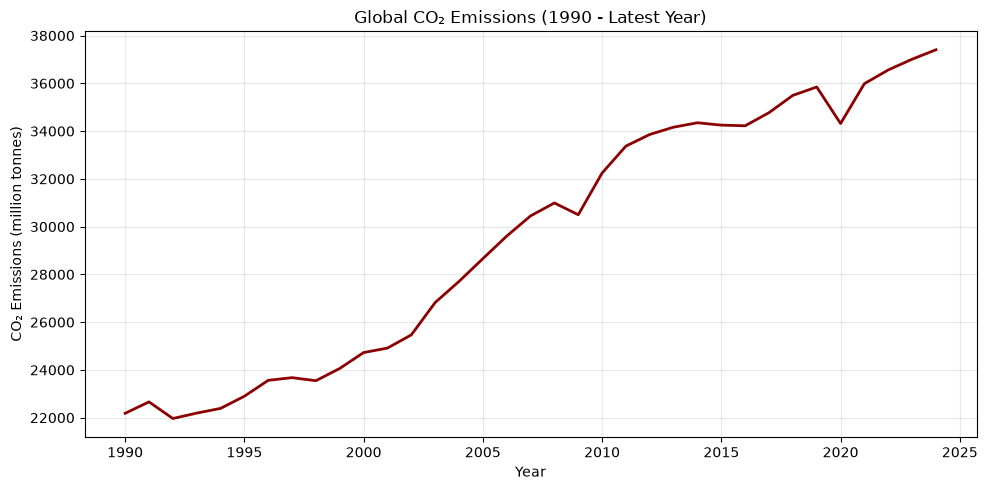

In [5]:
# Global CO2 emissions computed from the filtered sovereign-country dataset
global_co2 = df_filtered.groupby('year')['co2'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(global_co2['year'], global_co2['co2'], color='darkred', linewidth=2)
plt.title('Global CO\u2082 Emissions (1990 - Latest Year)')
plt.xlabel('Year')
plt.ylabel('CO\u2082 Emissions (million tonnes)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Summary — Global CO₂ Emissions Trend (1990–2024)**

Global CO₂ emissions increases 22,184 MtCO₂ in 1990 to about 37,406 MtCO₂ in 2024, an increase of approximately 69% over the 34-year period. The trend is upward and accelerates noticeably through the 2000s, reflecting rapid industrialisation in large developing economies. A clear dip is visible in 2020 (≈34,319 MtCO₂), corresponding to the global COVID-19 pandemic and the associated drop in industrial activity
. Emissions started increasing again just after 2020 & reached a all time by 2024.

*Note: these figures were computed from OWID's official 'World' row. Since this chart now sums the filtered sovereign countries instead, re-check these exact numbers against your new output and update if they've shifted slightly.*

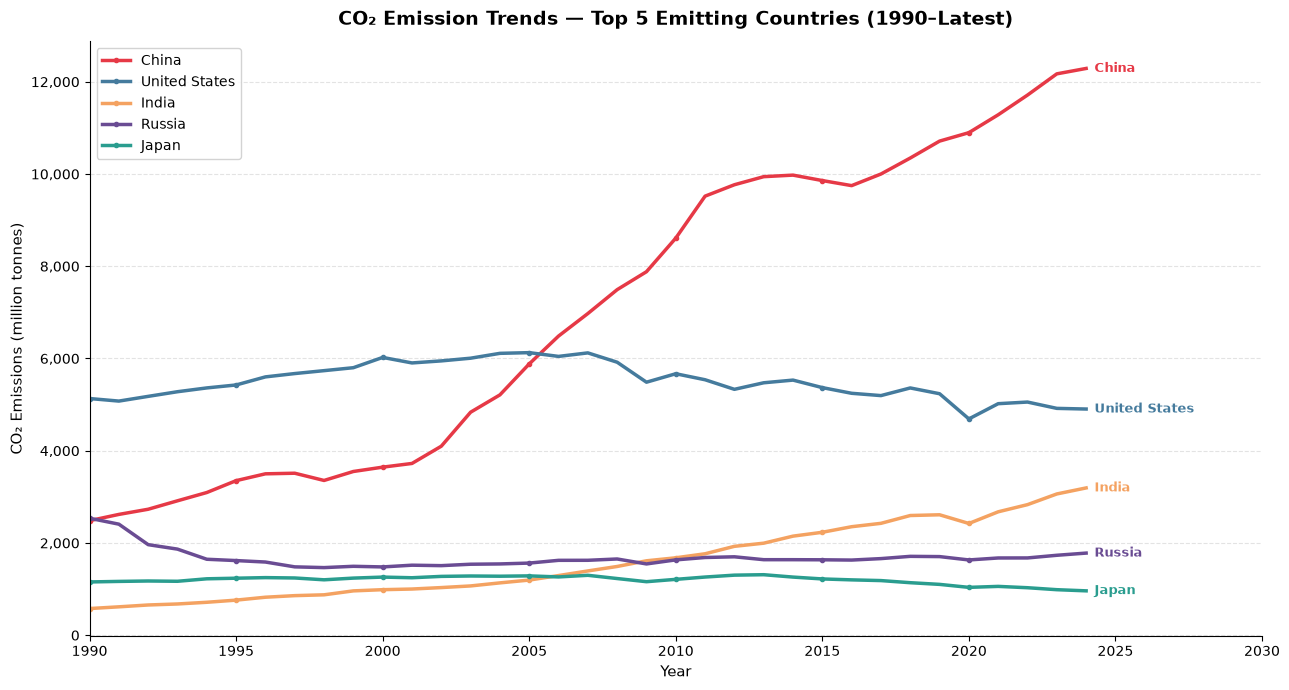

In [6]:
# Top 5 CO2 emitting countries, computed from the filtered dataset
top5 = ['China', 'United States', 'India', 'Russia', 'Japan']
colors_map = {
    'China':         '#E63946',
    'United States': '#457B9D',
    'India':         '#F4A261',
    'Russia':        '#6A4C93',
    'Japan':         '#2A9D8F',
}

df_top5 = df_filtered[df_filtered['country'].isin(top5)][['country', 'year', 'co2']].dropna()
df_pivot = df_top5.pivot(index='year', columns='country', values='co2')

fig, ax = plt.subplots(figsize=(13, 7))

for country in top5:
    if country in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[country],
                label=country, color=colors_map[country],
                linewidth=2.5, marker='o', markersize=3, markevery=5)
        last_yr  = df_pivot[country].dropna().index[-1]
        last_val = df_pivot[country].dropna().iloc[-1]
        ax.annotate(country,
                    xy=(last_yr, last_val), xytext=(6, 0),
                    textcoords='offset points', va='center',
                    fontsize=9, color=colors_map[country], fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(df_pivot.index.min(), df_pivot.index.max() + 6)
ax.set_title('CO\u2082 Emission Trends — Top 5 Emitting Countries (1990–Latest)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('CO\u2082 Emissions (million tonnes)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=10, framealpha=0.85)
plt.tight_layout()
plt.show()

**Summary — Top 5 Emitters Comparison (China, USA, India, Russia, Japan)**

In 1990, the United States was the clearly the most co2 emission contry roughly around 5000mtco2, almost double to china & russia, china co2 emission takes rapid growth around 2002 & it went on increaing rapidely leaving all countries behind, it is now leadig c02 emission country around the world. while usa maintained teir co2 emission the years. still it is the second highest co2 emission country around the world.india is also shows increasing in their co2 emission now at third position in the world, whilw russia & japan shows decrease in their co2 emission thats a great sign.

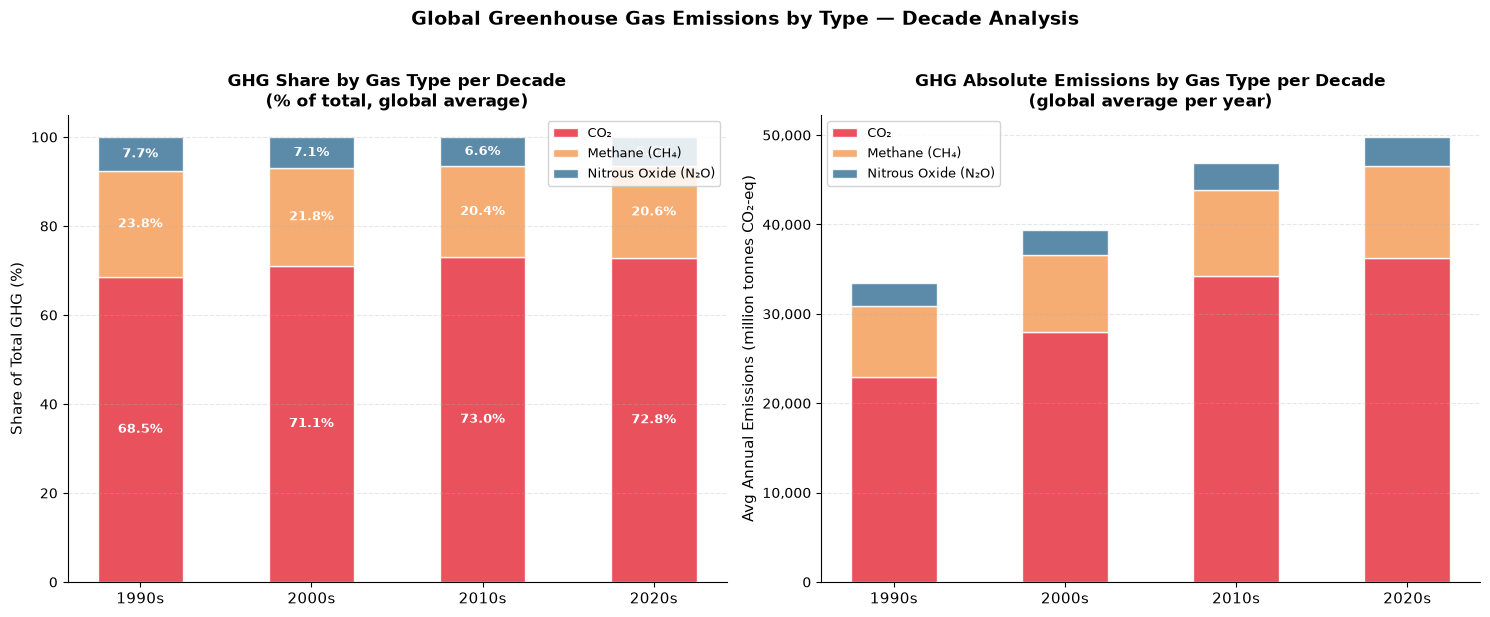

In [7]:
# Global GHG share by gas type per decade, computed from the filtered dataset
ghg_world = df_filtered.groupby('year')[['co2', 'methane', 'nitrous_oxide']].sum().reset_index()

def decade_label(y):
    if 1990 <= y <= 1999: return '1990s'
    elif 2000 <= y <= 2009: return '2000s'
    elif 2010 <= y <= 2019: return '2010s'
    elif y >= 2020:         return '2020s'
    else:                   return None

ghg_world['decade'] = ghg_world['year'].apply(decade_label)
ghg_world = ghg_world[ghg_world['decade'].notna()]

decade_avg = (
    ghg_world.groupby('decade')[['co2', 'methane', 'nitrous_oxide']]
    .mean()
    .reindex(['1990s', '2000s', '2010s', '2020s'])
)

decade_pct = decade_avg.div(decade_avg.sum(axis=1), axis=0) * 100

gas_labels = ['CO\u2082', 'Methane (CH\u2084)', 'Nitrous Oxide (N\u2082O)']
gas_colors = ['#E63946', '#F4A261', '#457B9D']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(decade_pct))
bottom = np.zeros(len(decade_pct))

for col, label, color in zip(decade_pct.columns, gas_labels, gas_colors):
    axes[0].bar(x, decade_pct[col], bottom=bottom,
                label=label, color=color, alpha=0.88, width=0.5, edgecolor='white')
    for i, (val, bot) in enumerate(zip(decade_pct[col], bottom)):
        if val > 3:
            axes[0].text(i, bot + val / 2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottom += decade_pct[col].values

axes[0].set_xticks(x)
axes[0].set_xticklabels(decade_pct.index, fontsize=11)
axes[0].set_ylabel('Share of Total GHG (%)', fontsize=11)
axes[0].set_title('GHG Share by Gas Type per Decade\n(% of total, global average)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].legend(loc='upper right', fontsize=9, framealpha=0.85)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

bottom2 = np.zeros(len(decade_avg))
for col, label, color in zip(decade_avg.columns, gas_labels, gas_colors):
    axes[1].bar(x, decade_avg[col], bottom=bottom2,
                label=label, color=color, alpha=0.88, width=0.5, edgecolor='white')
    bottom2 += decade_avg[col].values

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[1].set_xticks(x)
axes[1].set_xticklabels(decade_avg.index, fontsize=11)
axes[1].set_ylabel('Avg Annual Emissions (million tonnes CO\u2082-eq)', fontsize=11)
axes[1].set_title('GHG Absolute Emissions by Gas Type per Decade\n(global average per year)',
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9, framealpha=0.85)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Global Greenhouse Gas Emissions by Type — Decade Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Summary — Share of Global GHG by Gas Type per Decade**

CO₂ has consistently been the dominant greenhouse gas across all four decades, accounting for
roughly 68–73% of combined CO₂/methane/N₂O emissions throughout the period. Its share rose
steadily from about 68.5% in the 1990s to around 73% by the 2010s, before levelling off in the
2020s. Methane's share moved in the opposite direction, declining from roughly 23.8% in the
1990s to about 20.4–20.6% in the 2010s and 2020s, suggesting CO₂-generating activity (energy
and industry) has grown faster than methane-generating activity (agriculture, waste) over this
period. Nitrous oxide remains the smallest contributor throughout, shrinking modestly from
about 7.7% to 6.6% of the total. Overall, the composition has shifted modestly but consistently
toward CO₂ dominance over the three and a half decades covered.

*Note: recomputed from summed filtered-country data rather than OWID's 'World' row — percentages should be very close to before; re-check and update if any shifted.*

*****Week 2: Feature Engineering*****

In [8]:
# Reuse Week 1's filtered dataset as the single source of truth for Week 2
df_clean = df_filtered.copy().sort_values(['country', 'year']).reset_index(drop=True)

print(f"Filtered dataset shape : {df_clean.shape}")
print(f"Unique sovereign nations: {df_clean['country'].nunique()}")
print(f"Year range             : {df_clean['year'].min()} \u2013 {df_clean['year'].max()}")
df_clean[['country', 'year', 'co2', 'co2_per_capita', 'total_ghg', 'gdp', 'population']].head(5)

Filtered dataset shape : (7735, 80)
Unique sovereign nations: 221
Year range             : 1990 – 2024


,country,year,co2,co2_per_capita,total_ghg,gdp,population
0,Afghanistan,1990,2.024,0.168,13.519,1.306598e+10,12045664.0
1,Afghanistan,1991,1.914,0.156,13.711,1.204736e+10,12238879.0
2,Afghanistan,1992,1.482,0.112,11.543,1.267754e+10,13278983.0
3,Afghanistan,1993,1.487,0.100,10.454,9.834582e+09,14943175.0
4,Afghanistan,1994,1.454,0.089,10.980,7.919856e+09,16250800.0


In [9]:
# ── 2.1 Time-Based Features ──────────────────────────────────────────────

# Decade label: floor-divide year by 10, multiply back, append 's'
df_clean['decade'] = (df_clean['year'] // 10 * 10).astype(str) + 's'

# Simple numeric time index anchored at 1990
df_clean['years_since_1990'] = df_clean['year'] - 1990

# 5-year rolling average of CO2 per country (window=5, min_periods=1 avoids early NaNs)
df_clean['co2_5yr_rolling_mean'] = (
    df_clean
    .groupby('country')['co2']
    .transform(lambda series: series.rolling(window=5, min_periods=1).mean())
)

china_sample = (
    df_clean[df_clean['country'] == 'China']
    [['country', 'year', 'decade', 'years_since_1990', 'co2', 'co2_5yr_rolling_mean']]
    .head(10)
)
print("Sample output for China (first 10 rows after 1990):")
print(china_sample.to_string(index=False))

Sample output for China (first 10 rows after 1990):
country  year decade  years_since_1990      co2  co2_5yr_rolling_mean
  China  1990  1990s                 0 2483.534           2483.534000
  China  1991  1990s                 1 2619.143           2551.338500
  China  1992  1990s                 2 2731.290           2611.322333
  China  1993  1990s                 3 2914.284           2687.062750
  China  1994  1990s                 4 3093.891           2768.428400
  China  1995  1990s                 5 3351.197           2941.961000
  China  1996  1990s                 6 3499.311           3117.994600
  China  1997  1990s                 7 3512.350           3274.206600
  China  1998  1990s                 8 3355.336           3362.417000
  China  1999  1990s                 9 3549.949           3453.628600


**Lag features** capture a country's own recent emission history as predictors — `co2_lag1`, `co2_lag2`, `co2_lag3` are the CO₂ values from 1, 2, and 3 years prior for that same country. They're useful because emissions are highly autocorrelated (this year's value is strongly related to last year's), so lags let a model like Linear Regression or Random Forest learn from a country's own trajectory rather than only from static features like GDP or population.

In [10]:
# ── 2.2 Lag Features ────────────────────────────────────────────────

df_clean['co2_lag1'] = df_clean.groupby('country')['co2'].shift(1)
df_clean['co2_lag2'] = df_clean.groupby('country')['co2'].shift(2)
df_clean['co2_lag3'] = df_clean.groupby('country')['co2'].shift(3)

usa_sample = (
    df_clean[df_clean['country'] == 'United States']
    [['country', 'year', 'co2', 'co2_lag1', 'co2_lag2', 'co2_lag3']]
    .head(6)
)
print("Lag feature verification for United States:")
print(usa_sample.to_string(index=False))

print(f"\nNull counts for lag columns across full dataset:")
print(df_clean[['co2_lag1', 'co2_lag2', 'co2_lag3']].isnull().sum())
print("(Expected: 1× per country for lag1, 2× for lag2, 3× for lag3)")

Lag feature verification for United States:
      country  year      co2  co2_lag1  co2_lag2  co2_lag3
United States  1990 5131.761       NaN       NaN       NaN
United States  1991 5076.413  5131.761       NaN       NaN
United States  1992 5178.770  5076.413  5131.761       NaN
United States  1993 5279.520  5178.770  5076.413  5131.761
United States  1994 5361.863  5279.520  5178.770  5076.413
United States  1995 5425.837  5361.863  5279.520  5178.770

Null counts for lag columns across full dataset:
co2_lag1    412
co2_lag2    628
co2_lag3    844
dtype: int64
(Expected: 1× per country for lag1, 2× for lag2, 3× for lag3)


In [11]:
# 2.3a Verify co2_per_capita ──────────────────────────────

verification_countries = ['China', 'United States', 'India']
verification_years     = [2000, 2010, 2020]

verify_df = (
    df_clean[
        df_clean['country'].isin(verification_countries) &
        df_clean['year'].isin(verification_years)
    ]
    [['country', 'year', 'co2', 'population', 'co2_per_capita']]
    .copy()
)

verify_df['manual_co2_per_capita'] = (verify_df['co2'] * 1e6) / verify_df['population']
verify_df['difference'] = (
    verify_df['co2_per_capita'] - verify_df['manual_co2_per_capita']
).abs().round(6)

print("co2_per_capita cross-check (difference should be ≈ 0.0000):")
print(verify_df.to_string(index=False))

max_diff = verify_df['difference'].max()
if max_diff < 0.001:
    print(f"\n✓  Maximum absolute difference = {max_diff:.6f}  →  column is correctly computed.")
else:
    print(f"\n⚠  Maximum absolute difference = {max_diff:.6f}  →  investigate discrepancy.")

co2_per_capita cross-check (difference should be ≈ 0.0000):
      country  year       co2   population  co2_per_capita  manual_co2_per_capita  difference
        China  2000  3643.810 1269581174.0           2.870               2.870088    0.000088
        China  2010  8610.048 1351561505.0           6.370               6.370445    0.000445
        China  2020 10896.521 1426106093.0           7.641               7.640751    0.000249
        India  2000   987.065 1057922731.0           0.933               0.933022    0.000022
        India  2010  1678.530 1243481565.0           1.350               1.349863    0.000137
        India  2020  2422.732 1402617694.0           1.727               1.727293    0.000293
United States  2000  6023.158  281484126.0          21.398              21.397860    0.000140
United States  2010  5669.250  311062785.0          18.225              18.225420    0.000420
United States  2020  4689.954  339436156.0          13.817              13.816896    0.000104


In [12]:
# ── 2.3b GHG Intensity column ────────────────────────────────────────────

valid_mask = (
    df_clean['total_ghg'].notna() &
    df_clean['gdp'].notna() &
    (df_clean['gdp'] > 0)
)

df_clean['ghg_intensity'] = np.where(
    valid_mask,
    df_clean['total_ghg'] / df_clean['gdp'],
    np.nan
)

total_rows   = len(df_clean)
valid_rows   = valid_mask.sum()
missing_rows = total_rows - valid_rows

print(f"GHG intensity computed for : {valid_rows:,} rows ({valid_rows/total_rows:.1%})")
print(f"Missing (NaN)              : {missing_rows:,} rows ({missing_rows/total_rows:.1%})")

missing_by_country = (
    df_clean[df_clean['ghg_intensity'].isna()]
    .groupby('country')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='missing_years')
)
print("\nTop 10 countries with most missing ghg_intensity rows:")
print(missing_by_country.to_string(index=False))
print("\nNote: Missing values arise where GDP data is unavailable in the OWID dataset,")
print("      which is most common for very small or data-scarce nations.")

GHG intensity computed for : 5,377 rows (69.5%)
Missing (NaN)              : 2,358 rows (30.5%)

Top 10 countries with most missing ghg_intensity rows:
                        country  missing_years
                        Andorra             35
                          Aruba             35
            Antigua and Barbuda             35
                     Antarctica             35
                       Anguilla             35
                        Bermuda             35
                         Bhutan             35
                         Belize             35
Bonaire Sint Eustatius and Saba             35
                        Bahamas             35

Note: Missing values arise where GDP data is unavailable in the OWID dataset,
      which is most common for very small or data-scarce nations.


In [13]:
# ── 2.4 Growth Rate Features ──────────────────────────────────────────

df_clean['co2_yoy_change'] = (
    df_clean.groupby('country')['co2'].diff()
)

df_clean['co2_yoy_pct_change'] = (
    df_clean.groupby('country')['co2'].pct_change() * 100
)

sufficient_data_countries = (
    df_clean[df_clean['co2'].notna()]
    .groupby('country')['year']
    .count()
    [lambda s: s >= 10]
    .index
)

avg_pct_growth = (
    df_clean[df_clean['country'].isin(sufficient_data_countries)]
    .groupby('country')['co2_yoy_pct_change']
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={'co2_yoy_pct_change': 'avg_annual_pct_growth'})
)
avg_pct_growth['avg_annual_pct_growth'] = avg_pct_growth['avg_annual_pct_growth'].round(2)

print("Top 5 countries \u2014 highest average annual CO2 growth rate since 1990:")
print(avg_pct_growth.to_string(index=False))

Top 5 countries — highest average annual CO2 growth rate since 1990:
                  country  avg_annual_pct_growth
               East Timor                    inf
                   Kosovo                    inf
        Equatorial Guinea                  52.69
                   Kuwait                  37.86
Sint Maarten (Dutch part)                  22.45


In [14]:
# ── Top 5 largest absolute CO2 reductions since 1990 ───────────────────────

co2_net_change = (
    df_clean[
        df_clean['co2'].notna() &
        df_clean['country'].isin(sufficient_data_countries)
    ]
    .groupby('country')
    .apply(lambda grp: grp.loc[grp['year'].idxmax(), 'co2'] - grp.loc[grp['year'].idxmin(), 'co2'])
    .dropna()
    .sort_values()
    .head(5)
    .reset_index()
    .rename(columns={0: 'net_co2_change_mt'})
)
co2_net_change['net_co2_change_mt'] = co2_net_change['net_co2_change_mt'].round(2)

print("Top 5 countries \u2014 largest absolute CO2 reductions (MtCO2) from 1990 to latest year:")
print(co2_net_change.to_string(index=False))

Top 5 countries — largest absolute CO2 reductions (MtCO2) from 1990 to latest year:
       country  net_co2_change_mt
        Russia            -755.76
       Ukraine            -564.03
       Germany            -482.48
United Kingdom            -289.04
 United States            -227.64


In [15]:
# ── 2.5 Assemble and save the final modelling DataFrame ─────────────────────

PROJECT_COUNTRIES = [
    'China', 'United States', 'India', 'Russia', 'Japan',
    'Germany', 'South Africa', 'Canada', 'Brazil', 'United Kingdom'
]

FEATURE_COLUMNS = [
    'country', 'year',
    'co2', 'co2_per_capita',
    'co2_5yr_rolling_mean',
    'co2_lag1', 'co2_lag2', 'co2_lag3',
    'co2_yoy_pct_change',
    'ghg_intensity'
]

df_model = (
    df_clean[df_clean['country'].isin(PROJECT_COUNTRIES)][FEATURE_COLUMNS]
    .reset_index(drop=True)
)

print("Final modelling DataFrame \u2014 shape:", df_model.shape)
print(f"Countries  : {df_model['country'].nunique()} × {df_model['year'].nunique()} years each")
print()
print("Null value summary:")
null_summary = df_model.isnull().sum().reset_index()
null_summary.columns = ['column', 'null_count']
null_summary['null_pct'] = (null_summary['null_count'] / len(df_model) * 100).round(1)
print(null_summary.to_string(index=False))

Final modelling DataFrame — shape: (350, 10)
Countries  : 10 × 35 years each

Null value summary:
              column  null_count  null_pct
             country           0       0.0
                year           0       0.0
                 co2           0       0.0
      co2_per_capita           0       0.0
co2_5yr_rolling_mean           0       0.0
            co2_lag1          10       2.9
            co2_lag2          20       5.7
            co2_lag3          30       8.6
  co2_yoy_pct_change          10       2.9
       ghg_intensity          20       5.7


In [16]:
# Preview the final dataset
print("First 15 rows of ghg_features.csv:")
df_model.head(15)

First 15 rows of ghg_features.csv:


,country,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
0,Brazil,1990,218.658,1.466,218.658000,NaN,NaN,NaN,NaN,1.775912e-09
1,Brazil,1991,229.394,1.512,224.026000,218.658,NaN,NaN,4.909951,1.804642e-09
2,Brazil,1992,233.601,1.514,227.217667,229.394,218.658,NaN,1.833963,1.856175e-09
3,Brazil,1993,244.306,1.558,231.489750,233.601,229.394,218.658,4.582600,1.758166e-09
4,Brazil,1994,254.002,1.595,235.992200,244.306,233.601,229.394,3.968793,1.920481e-09
5,Brazil,1995,268.678,1.661,245.996200,254.002,244.306,233.601,5.777907,1.801317e-09
6,Brazil,1996,289.311,1.762,257.979600,268.678,254.002,244.306,7.679453,1.701512e-09
7,Brazil,1997,306.949,1.842,272.649200,289.311,268.678,254.002,6.096554,1.694040e-09
8,Brazil,1998,317.359,1.876,287.259800,306.949,289.311,268.678,3.391443,1.810991e-09
9,Brazil,1999,327.256,1.907,301.910600,317.359,306.949,289.311,3.118550,1.801887e-09


In [17]:
# Save to CSV
output_path = 'ghg_features.csv'
df_model.to_csv(output_path, index=False)
print(f"Saved: {output_path}  ({len(df_model)} rows × {len(df_model.columns)} columns)")

df_reload = pd.read_csv(output_path)
assert df_reload.shape == df_model.shape, "Shape mismatch after reload!"
print("✓  Reload check passed \u2014 file is intact and ready to commit to GitHub.")

Saved: ghg_features.csv  (350 rows × 10 columns)
✓  Reload check passed — file is intact and ready to commit to GitHub.


In [18]:
# ── Summary statistics for the final feature set ─────────────────────
print("Descriptive statistics for numeric feature columns:")
df_model.describe().round(3)

Descriptive statistics for numeric feature columns:


,year,co2,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity
count,350.000,350.000,350.000,350.000,340.000,330.000,320.000,340.000,330.0
mean,2007.000,1962.617,9.058,1901.890,1945.428,1927.893,1910.830,0.916,0.0
std,10.114,2467.088,5.449,2341.167,2425.926,2383.095,2342.668,4.590,0.0
min,1990.000,218.658,0.668,218.658,218.658,218.658,218.658,-18.449,0.0
25%,1998.000,500.045,4.535,506.892,505.198,508.808,510.872,-1.781,0.0
50%,2007.000,919.377,9.363,917.380,919.377,919.377,919.377,1.040,0.0
75%,2016.000,1776.817,11.490,1781.070,1741.275,1708.547,1705.822,3.611,0.0
max,2024.000,12289.037,21.398,11670.755,12172.009,11711.808,11284.401,17.985,0.0


# Week 3: Baseline ML Models – Regression

### 3.1 Problem Framing

**Prediction task:** Given a feature vector X describing country C in year Y (its CO₂ per-capita, 5-year rolling mean, lagged CO₂ values, year-on-year growth rate, and GHG intensity), predict that country's CO₂ emissions in year Y+1.

**Target variable:** `co2` — specifically `co2_next_year`, built by shifting each country's `co2` column back by one row so the label for year Y is the actual CO₂ value recorded in year Y+1.

**Input features:** `co2_per_capita`, `co2_5yr_rolling_mean`, `co2_lag1`, `co2_lag2`, `co2_lag3`, `co2_yoy_pct_change`, `ghg_intensity`, and `years_since_1990` — all carried over from Week 2's `df_model`.

**Why a supervised regression approach:** CO₂ emissions are a continuous numeric quantity, and historical labeled examples exist (year Y's features → year Y+1's actual emissions). Regression maps a country's current profile directly to a predicted numeric value and preserves magnitude of error — being off by 5 Mt vs 500 Mt should be scored very differently, which classification would not capture.

In [19]:
# ── Build modelling frame: add years_since_1990 and the next-year target ─────

model_df = df_model.copy()
model_df['years_since_1990'] = model_df['year'] - 1990
model_df['co2_next_year'] = model_df.groupby('country')['co2'].shift(-1)
model_df = model_df.dropna(subset=['co2_next_year']).reset_index(drop=True)

FEATURE_COLS = ['co2_per_capita', 'co2_5yr_rolling_mean', 'co2_lag1', 'co2_lag2',
                'co2_lag3', 'co2_yoy_pct_change', 'ghg_intensity', 'years_since_1990']
TARGET_COL = 'co2_next_year'

print(f"Countries: {model_df['country'].nunique()} | Rows for modelling: {len(model_df)}")
print("\nPercent missing per feature:")
print((model_df[FEATURE_COLS].isna().mean() * 100).round(2))

Countries: 10 | Rows for modelling: 340

Percent missing per feature:
co2_per_capita          0.00
co2_5yr_rolling_mean    0.00
co2_lag1                2.94
co2_lag2                5.88
co2_lag3                8.82
co2_yoy_pct_change      2.94
ghg_intensity           2.94
years_since_1990        0.00
dtype: float64


### 3.2 Train-Test Split — Temporal, Not Random

Data is split by year, not shuffled randomly: **1990–2018 for training, 2019–2023 for testing.** Random splitting would let the model train on rows that come *after* some test rows chronologically — effectively letting it "see the future" during training, which inflates apparent accuracy and misrepresents how the model would actually be used (forecasting years that haven't happened from years that have). The 2019–2023 test window also deliberately includes the COVID-19 emissions dip (2020) and the recovery afterward — a real-world stress test of whether the model still performs reasonably when the future doesn't look like a simple continuation of the past.

In [20]:
train_df = model_df[model_df['year'].between(1990, 2018)].copy()
test_df  = model_df[model_df['year'].between(2019, 2023)].copy()

split_summary = pd.DataFrame({
    'Country': PROJECT_COUNTRIES,
    'Train Samples': [len(train_df[train_df['country'] == c]) for c in PROJECT_COUNTRIES],
    'Test Samples':  [len(test_df[test_df['country'] == c]) for c in PROJECT_COUNTRIES],
})
split_summary

,Country,Train Samples,Test Samples
0,China,29,5
1,United States,29,5
2,India,29,5
3,Russia,29,5
4,Japan,29,5
5,Germany,29,5
6,South Africa,29,5
7,Canada,29,5
8,Brazil,29,5
9,United Kingdom,29,5


### 3.3 Naive Baseline Model

Predicted CO₂ for year Y+1 = actual CO₂ in year Y (no-change assumption). Any model built afterward should beat this baseline to be considered useful.

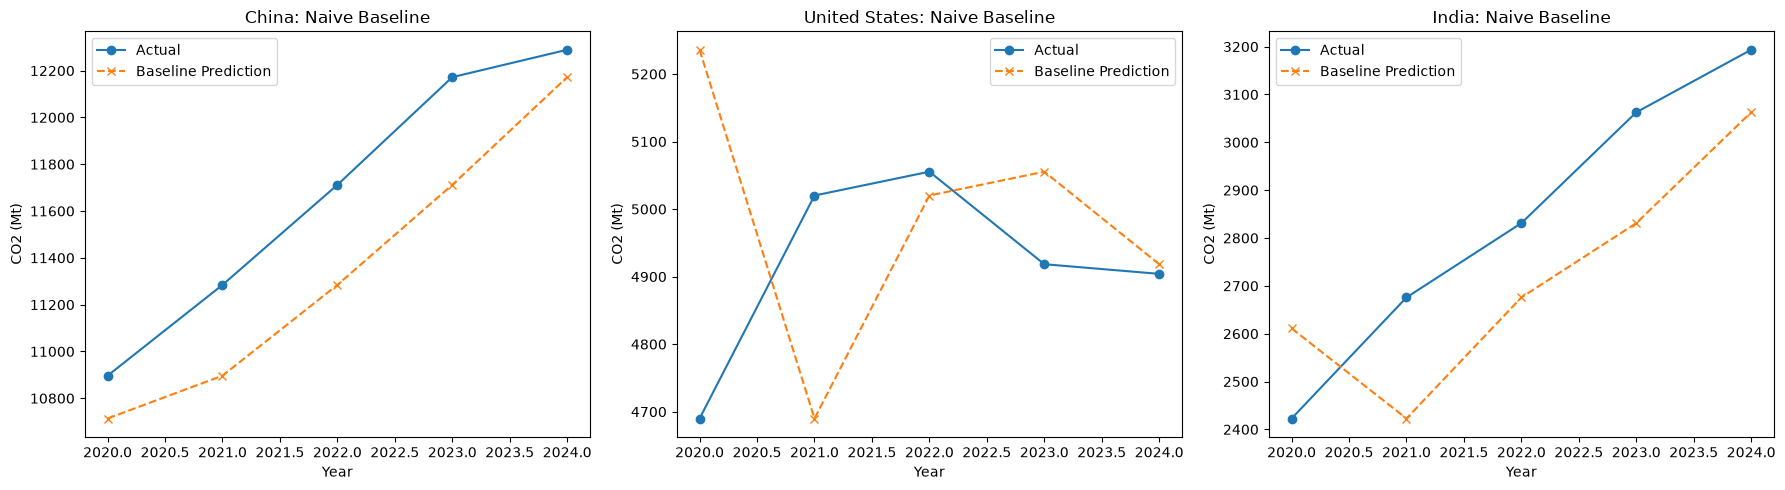

,Country,Baseline MAE,Baseline RMSE
0,China,315.1044,344.121882
1,United States,212.5380,292.332458
2,India,191.8378,197.188147
3,Russia,44.2358,50.307134
4,Japan,36.5260,39.830915
5,Germany,39.5944,46.431112
6,South Africa,12.2652,17.077892
7,Canada,18.5134,26.209789
8,Brazil,19.7412,26.352645
9,United Kingdom,18.8426,23.468566


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

plot_countries = PROJECT_COUNTRIES[:3]  # swap in specific country names if you prefer
baseline_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for country in PROJECT_COUNTRIES:
    test_c = test_df[test_df['country'] == country].dropna(subset=['co2', TARGET_COL]).sort_values('year')
    if len(test_c) == 0:
        continue
    mae = mean_absolute_error(test_c[TARGET_COL], test_c['co2'])
    rmse = np.sqrt(mean_squared_error(test_c[TARGET_COL], test_c['co2']))
    baseline_results.append({'Country': country, 'Baseline MAE': mae, 'Baseline RMSE': rmse})

    if country in plot_countries:
        ax = axes[plot_countries.index(country)]
        ax.plot(test_c['year'] + 1, test_c[TARGET_COL], marker='o', label='Actual')
        ax.plot(test_c['year'] + 1, test_c['co2'], marker='x', linestyle='--', label='Baseline Prediction')
        ax.set_title(f'{country}: Naive Baseline')
        ax.set_xlabel('Year'); ax.set_ylabel('CO2 (Mt)'); ax.legend()

plt.tight_layout()
plt.show()

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

### 3.4 Linear Regression

A separate model is trained per country (rather than one pooled model across all 10) so each country's own emissions scale and dynamics are captured directly, instead of being averaged across countries with very different absolute emission levels.

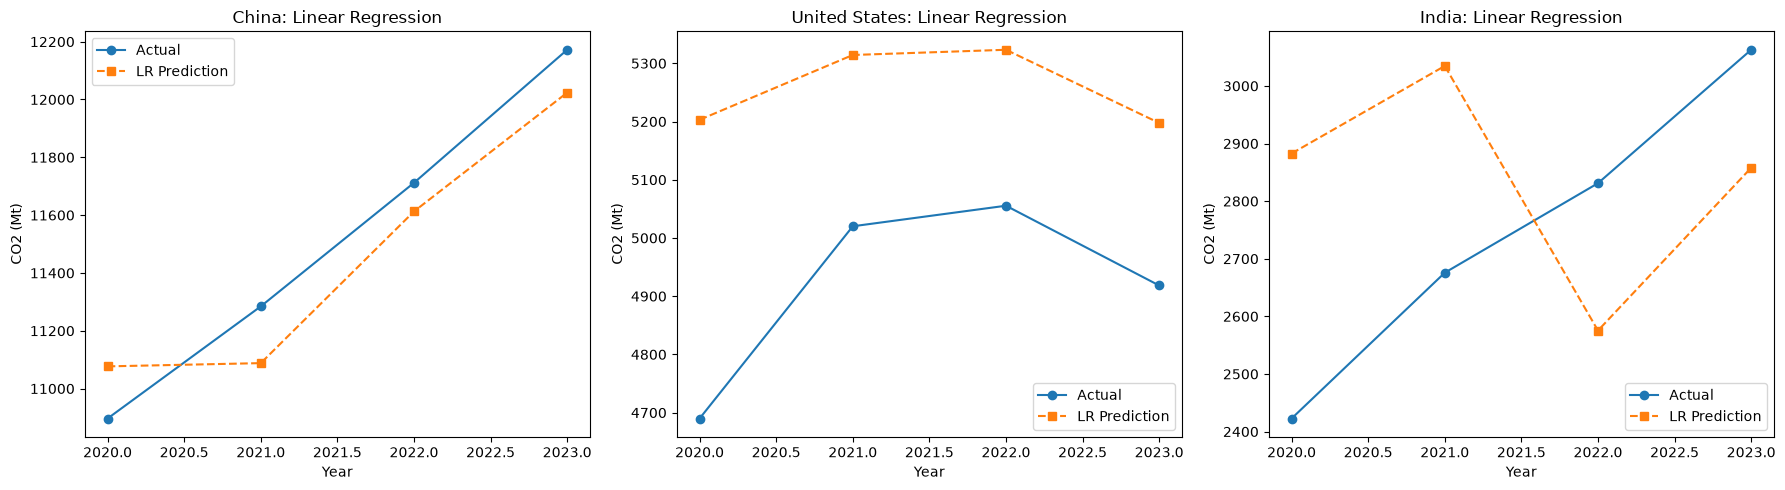

,Country,LR MAE,LR RMSE
0,China,155.999065,160.361454
1,United States,338.550415,353.342122
2,India,319.862523,334.567195
3,Russia,30.629178,32.803571
4,Japan,31.148249,36.011568
5,Germany,83.657652,93.452758
6,South Africa,12.830270,17.524498
7,Canada,31.884360,33.374652
8,Brazil,46.702908,52.695236
9,United Kingdom,24.800032,26.780811


,co2_per_capita,co2_5yr_rolling_mean,co2_lag1,co2_lag2,co2_lag3,co2_yoy_pct_change,ghg_intensity,years_since_1990
China,1778.822981,1.464624,-1.150733,0.009363,-0.746772,-13.223276,2.966948e-07,84.988651
United States,796.103913,-0.095283,-2.211594,0.411615,0.056546,-112.882357,-4.774369e+12,69.565576
India,-1802.327878,-1.038074,2.927391,0.465246,-0.284171,27.324908,6.923225e+11,19.782185
Russia,9.339283,0.355945,-0.125313,-0.125260,0.140750,3.332880,-1.495886e+11,2.196534
Japan,-346.767144,1.299121,2.080056,-0.066862,-0.499258,32.257690,3.504035e+12,5.021365
Germany,21.530528,0.875112,-0.372436,-0.484151,-0.422354,-3.175247,1.962404e+10,-9.142135
South Africa,-16.541699,-1.738940,1.661512,0.353486,0.380332,5.956013,-1.613088e+11,-4.632162
Canada,106.629375,-0.345230,-2.923622,0.440975,0.061753,-14.589112,6.932439e+10,19.579428
Brazil,285.161531,-1.557669,-0.214653,0.390445,0.056043,-2.276782,-1.682912e+10,13.789176
United Kingdom,14.520361,1.876898,-0.070399,-0.569102,-0.590056,-0.001728,-8.490121e+11,-11.601708


In [22]:
from sklearn.linear_model import LinearRegression

lr_results, lr_models = [], {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for country in PROJECT_COUNTRIES:
    train_c = train_df[train_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    test_c  = test_df[test_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    if len(train_c) < 5 or len(test_c) == 0:
        continue

    model = LinearRegression().fit(train_c[FEATURE_COLS], train_c[TARGET_COL])
    y_pred = model.predict(test_c[FEATURE_COLS])

    lr_results.append({
        'Country': country,
        'LR MAE': mean_absolute_error(test_c[TARGET_COL], y_pred),
        'LR RMSE': np.sqrt(mean_squared_error(test_c[TARGET_COL], y_pred)),
    })
    lr_models[country] = model

    if country in plot_countries:
        ax = axes[plot_countries.index(country)]
        ax.plot(test_c['year'] + 1, test_c[TARGET_COL], marker='o', label='Actual')
        ax.plot(test_c['year'] + 1, y_pred, marker='s', linestyle='--', label='LR Prediction')
        ax.set_title(f'{country}: Linear Regression')
        ax.set_xlabel('Year'); ax.set_ylabel('CO2 (Mt)'); ax.legend()

plt.tight_layout()
plt.show()

lr_results_df = pd.DataFrame(lr_results)
coef_table = pd.DataFrame({c: m.coef_ for c, m in lr_models.items()}, index=FEATURE_COLS).T
display(lr_results_df)
display(coef_table)

**Interpreting the coefficients — fill this in after running the cell above:** look at `coef_table` and, for at least 2–3 specific countries, name the feature(s) with the largest absolute coefficient. In emissions data this is often `co2_lag1` or `co2_5yr_rolling_mean`, since next year's value is usually close to a smoothed version of recent history — but confirm this against your actual numbers rather than assuming it, since coefficient scale depends on each feature's own units and range.

### 3.5 Random Forest Regressor

Random Forest can capture non-linear relationships and interactions between features that Linear Regression cannot, at the cost of being less directly interpretable — hence the feature importance chart in place of coefficients.

,Country,RF MAE,RF RMSE
0,China,1033.025205,1134.283262
1,United States,365.095600,391.045867
2,India,263.123073,304.279749
3,Russia,35.281490,41.886663
4,Japan,118.071585,122.339766
5,Germany,91.570208,97.437567
6,South Africa,25.067375,25.537930
7,Canada,28.034590,29.889728
8,Brazil,19.195175,22.224623
9,United Kingdom,52.719502,54.373688


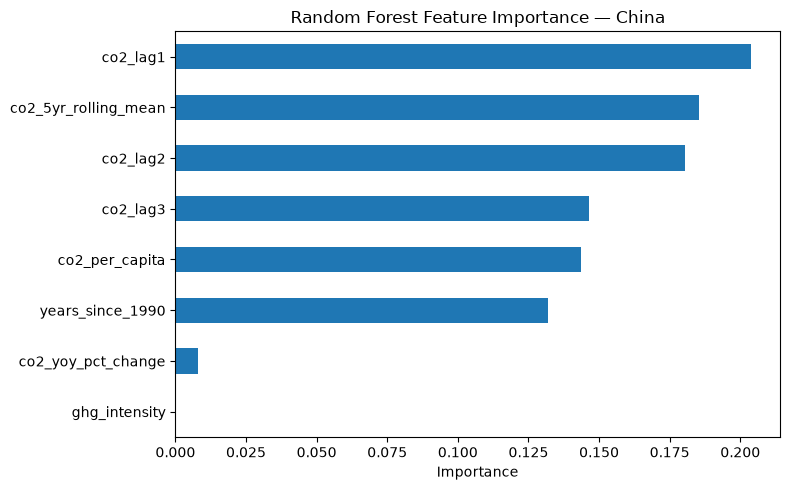

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_results, rf_models = [], {}

for country in PROJECT_COUNTRIES:
    train_c = train_df[train_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    test_c  = test_df[test_df['country'] == country].dropna(subset=FEATURE_COLS + [TARGET_COL])
    if len(train_c) < 5 or len(test_c) == 0:
        continue

    model = RandomForestRegressor(n_estimators=100, random_state=42).fit(train_c[FEATURE_COLS], train_c[TARGET_COL])
    y_pred = model.predict(test_c[FEATURE_COLS])

    rf_results.append({
        'Country': country,
        'RF MAE': mean_absolute_error(test_c[TARGET_COL], y_pred),
        'RF RMSE': np.sqrt(mean_squared_error(test_c[TARGET_COL], y_pred)),
    })
    rf_models[country] = model

rf_results_df = pd.DataFrame(rf_results)
display(rf_results_df)

example_country = plot_countries[0]
if example_country in rf_models:
    importances = pd.Series(rf_models[example_country].feature_importances_, index=FEATURE_COLS).sort_values()
    plt.figure(figsize=(8, 5))
    importances.plot(kind='barh')
    plt.title(f'Random Forest Feature Importance — {example_country}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

### 3.6 Model Comparison

In [24]:
comparison_df = baseline_results_df.merge(lr_results_df, on='Country').merge(rf_results_df, on='Country')

comparison_df['Best Model'] = comparison_df.apply(
    lambda r: min({'Baseline': r['Baseline MAE'], 'LR': r['LR MAE'], 'RF': r['RF MAE']},
                  key=lambda k: r[{'Baseline':'Baseline MAE','LR':'LR MAE','RF':'RF MAE'}[k]]),
    axis=1
)
comparison_df = comparison_df[['Country', 'Baseline MAE', 'LR MAE', 'RF MAE', 'Baseline RMSE', 'LR RMSE', 'RF RMSE', 'Best Model']]
comparison_df

,Country,Baseline MAE,LR MAE,RF MAE,Baseline RMSE,LR RMSE,RF RMSE,Best Model
0,China,315.1044,155.999065,1033.025205,344.121882,160.361454,1134.283262,LR
1,United States,212.5380,338.550415,365.095600,292.332458,353.342122,391.045867,Baseline
2,India,191.8378,319.862523,263.123073,197.188147,334.567195,304.279749,Baseline
3,Russia,44.2358,30.629178,35.281490,50.307134,32.803571,41.886663,LR
4,Japan,36.5260,31.148249,118.071585,39.830915,36.011568,122.339766,LR
5,Germany,39.5944,83.657652,91.570208,46.431112,93.452758,97.437567,Baseline
6,South Africa,12.2652,12.830270,25.067375,17.077892,17.524498,25.537930,Baseline
7,Canada,18.5134,31.884360,28.034590,26.209789,33.374652,29.889728,Baseline
8,Brazil,19.7412,46.702908,19.195175,26.352645,52.695236,22.224623,RF
9,United Kingdom,18.8426,24.800032,52.719502,23.468566,26.780811,54.373688,Baseline


**Conclusion — fill this in after running the cell above, based on your actual `comparison_df`:**
1. How many of the 10 countries had Baseline vs LR vs RF as the best model?
2. Did either trained model consistently beat the naive baseline, or did the baseline hold up surprisingly well (common in emissions data, since year-to-year change is often small relative to the noise a small model can introduce)?
3. Name 1–2 countries where the gap between best and worst model is largest, and connect that to what you saw in the coefficient table / feature importance chart above.

# Week 4: Exponential Smoothing (ETS)

### Holt's Damped Trend — ETS(A,Ad,N)

For each of the 10 countries, fit Holt's damped trend exponential smoothing on the 1990–2018 training series (raw annual `co2`, not the shifted regression target). This models the level and trend of each country's own emissions history directly, independent of the lag/rolling features used in Week 3.

In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

ets_fits = {}
ets_params = []

for country in PROJECT_COUNTRIES:
    train_co2 = (
        train_df[train_df['country'] == country]
        .sort_values('year')
        .set_index('year')['co2']
        .dropna()
    )

    model = ExponentialSmoothing(train_co2, trend='add', damped_trend=True, seasonal=None)
    fit = model.fit(optimized=True)
    ets_fits[country] = fit

    ets_params.append({
        'Country': country,
        'alpha (level)':  round(fit.params['smoothing_level'], 4),
        'beta* (trend)':  round(fit.params['smoothing_trend'], 4),
        'phi (damping)':  round(fit.params['damping_trend'], 4),
    })

ets_params_df = pd.DataFrame(ets_params)
ets_params_df

,Country,alpha (level),beta* (trend),phi (damping)
0,China,1.0000,0.8653,0.8730
1,United States,0.7213,0.1879,0.8695
2,India,0.6456,0.6456,0.9950
3,Russia,0.4390,0.4390,0.8000
4,Japan,1.0000,0.0000,0.8356
5,Germany,0.0000,0.0000,0.9687
6,South Africa,0.7110,0.0000,0.9475
7,Canada,0.8380,0.0000,0.9240
8,Brazil,1.0000,0.0000,0.9701
9,United Kingdom,0.5215,0.3995,0.9757


In [26]:
print("Fitted ETS(A,Ad,N) parameters for 3 example countries:\n")
for country in PROJECT_COUNTRIES[:3]:
    p = ets_fits[country].params
    print(f"{country}:")
    print(f"  alpha (smoothing level) = {p['smoothing_level']:.4f}")
    print(f"  beta*  (smoothing trend) = {p['smoothing_trend']:.4f}")
    print(f"  phi   (damping trend)   = {p['damping_trend']:.4f}\n")

Fitted ETS(A,Ad,N) parameters for 3 example countries:

China:
  alpha (smoothing level) = 1.0000
  beta*  (smoothing trend) = 0.8653
  phi   (damping trend)   = 0.8730

United States:
  alpha (smoothing level) = 0.7213
  beta*  (smoothing trend) = 0.1879
  phi   (damping trend)   = 0.8695

India:
  alpha (smoothing level) = 0.6456
  beta*  (smoothing trend) = 0.6456
  phi   (damping trend)   = 0.9950



**Interpreting φ (phi, the damping parameter) — check this against your actual `ets_params_df` output:**

- **φ close to 1** means almost no damping — the model believes the current trend (growth or decline) will continue at nearly full strength far into the future. A country with φ ≈ 0.99–0.995 will show a forecast that keeps rising or falling steeply for many years, which can be unrealistic if extrapolated too far.
- **φ noticeably below 1** (e.g. ≈ 0.8–0.9) means the trend fades out faster — the model expects growth or decline to flatten toward a stable level within a shorter horizon, which is often more physically plausible for emissions (economies mature, policies shift, growth rates rarely stay constant for decades).
- **φ at or very near the optimizer's boundary** (extremely close to 0 or 1) can be a sign the optimizer struggled to find an interior solution — worth flagging as a potentially unreliable fit rather than treating it as a confident estimate, and worth double-checking against the actual training series for that country.

**Fill in with your specific countries:** name which of your 3 printed countries has the highest φ and which has the lowest, and state what that implies for each country's emissions trajectory specifically — e.g. a persistently rising trend vs one that's expected to plateau.